In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


c:\Users\Alice\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Alice\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


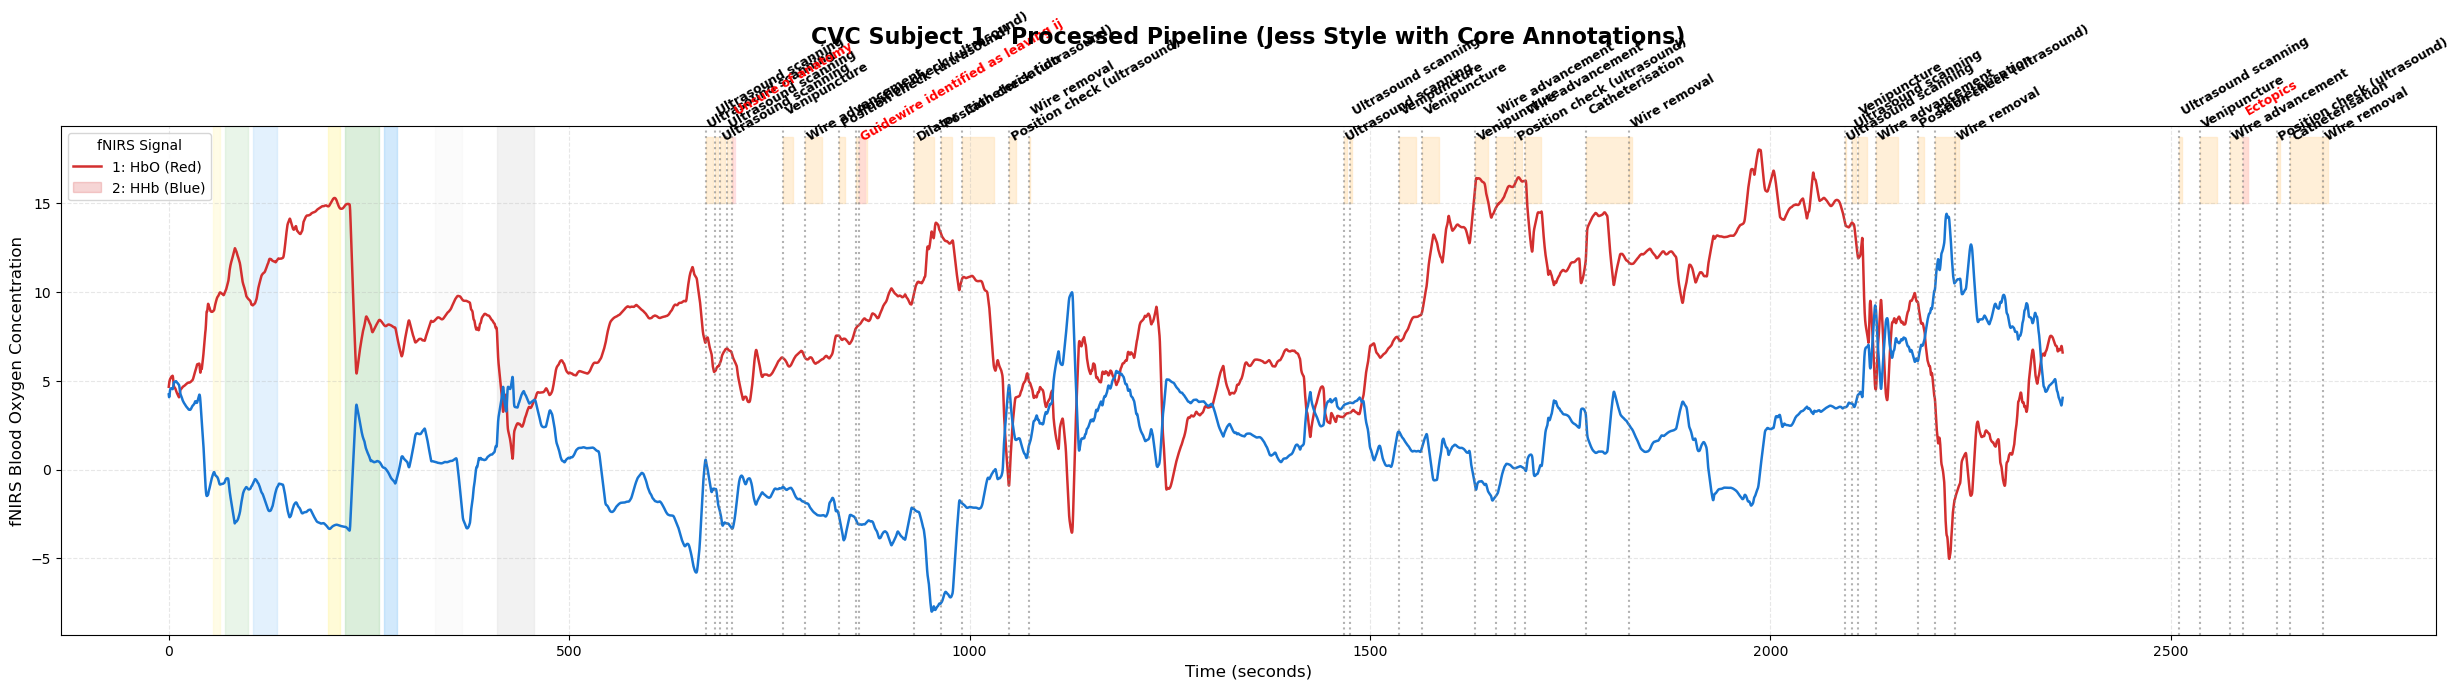

🌟 带有10个核心标注的完美长图已成功生成并保存！


In [2]:

# ==========================================
# 1. 设定参数与数据加载
# ==========================================
subj_id = '1'
sess_id = '1'
y_col = 'Var50'  # 真实的有效脑血流通道

# 读取时序数据和 MATLAB 提取出的粗略事件
ts_data = pd.read_csv(f'cvc_time_series_data/ts_subj_{subj_id}_sess_{sess_id}.csv')
events_mat = pd.read_csv(f'cvc_event_data/event_subj_{subj_id}_sess_{sess_id}.csv')

# 读取我们刚从 .eaf 提取出的 106 个微观标注
elan_df = pd.read_csv('CVC_0001_Annotations.csv')

# ==========================================
# 2. 核心标注数据的清洗与【白名单筛选】
# ==========================================
# 只保留 Stage 和 Event
filtered_elan = elan_df[elan_df['Tier'].isin(['Stage', 'Event'])].copy()

# 清洗文本格式
filtered_elan['Clean_Text'] = filtered_elan['Text'].str.strip().str.replace(r'\s+', ' ', regex=True).str.capitalize()

# 修正拼写和合并同类项
correction_dict = {
    'Postion check (ultrasound)': 'Position check (ultrasound)',
    'Clinical query odp': 'Clinical query',
    'Wire removal (with catheter)': 'Wire removal',
    'Wire in and minimal advancement': 'Wire advancement',
    'Other: guidewire identified as leaving ij - not happy with anatomy': 'Guidewire identified as leaving ij'
}
filtered_elan['Clean_Text'] = filtered_elan['Clean_Text'].replace(correction_dict)

# 10 个核心核心手术步骤与突发事件白名单
core_whitelist = [
    'Venipuncture', 'Position check (ultrasound)', 'Ultrasound scanning', 
    'Catheterisation', 'Wire advancement', 'Wire removal', 'Dilator', 
    'Guidewire identified as leaving ij', 'Unsure of anatomy', 'Ectopics'
]

# 最终过滤：只留下这 10 种核心词汇的行
df_core_stages = filtered_elan[filtered_elan['Clean_Text'].isin(core_whitelist)].copy()

# ==========================================
# 3. 数据平滑处理 (让线条丝滑如老师的样例)
# ==========================================
ts_data['Smoothed'] = ts_data.groupby('signal')[y_col].transform(lambda x: x.rolling(window=40, min_periods=1).mean())

# ==========================================
# 4. 开始绘制一镜到底的 Jess 风格长图
# ==========================================
plt.figure(figsize=(25, 7))
ax = sns.lineplot(data=ts_data, x='timestamp', y='Smoothed', hue='signal', 
                 palette={1: "#d32f2f", 2: "#1976d2"}, linewidth=1.8)

# --- 步骤 A：绘制宏观的 Block 背景底色（从 MATLAB 来的大色块） ---
color_map = {
    33: '#fff9c4', 4: '#c8e6c9', 7: '#bbdefb',   # Low WL Block A, B, C (浅黄、浅绿、浅蓝)
    14: '#fff59d', 17: '#a5d6a7', 20: '#90caf9', # High WL Block A, B, C
    30: '#f5f5f5', 10: '#e0e0e0'                # Continuous (灰色)
}

for evt_id, color in color_map.items():
    of_interest = events_mat[events_mat['id'] == evt_id]
    for i in range(len(of_interest)):
        start_idx = int(of_interest['onsets'].iloc[i])
        end_idx = start_idx + int(of_interest['durations'].iloc[i])
        if end_idx < len(ts_data):
            t_start = ts_data['timestamp'].iloc[start_idx]
            t_end = ts_data['timestamp'].iloc[end_idx]
            ax.axvspan(t_start, t_end, color=color, alpha=0.4)

# --- 步骤 B：绘制微观的 10 个 Core Annotations（从 ELAN 来的标签和小旗子） ---
y_max = ts_data['Smoothed'].max()
y_min = ts_data['Smoothed'].min()
y_range = y_max - y_min

# 遍历我们筛选出来的核心动作
for idx, row in df_core_stages.iterrows():
    # 核心转换：将毫秒转换为秒
    t_start_sec = row['Start_ms'] / 1000.0
    t_end_sec = row['End_ms'] / 1000.0
    text = row['Clean_Text']
    
    # 画一条细虚线指示动作发生的精准起点位置
    ax.axvline(x=t_start_sec, color='grey', linestyle=':', alpha=0.6)
    
    # 配合精细色块指示动作持续区间
    # 突发错误（如Unsure或Guidewire leaving）用淡红色高亮，正常步骤用淡橘色
    span_color = '#ffcdd2' if text in ['Unsure of anatomy', 'Guidewire identified as leaving ij', 'Ectopics'] else '#ffe0b2'
    ax.axvspan(t_start_sec, t_end_sec, ymin=0.85, ymax=0.98, color=span_color, alpha=0.5)
    
    # 错落排版魔法：利用循环让文字在顶部高低错开，防止左右挨得太近时重叠
    # 高度在 y_max 的 1.02倍、1.06倍、1.10倍 之间循环切换
    offset_factor = 1.02 + (idx % 3) * 0.04
    text_y_pos = y_max * offset_factor
    
    # 如果是突发错误，字变成红色，引起警觉；常规动作文本用黑色
    font_color = 'red' if text in ['Unsure of anatomy', 'Guidewire identified as leaving ij', 'Ectopics'] else 'black'
    
    # 在图表上方打上干净的动作标签
    ax.text(t_start_sec, text_y_pos, text, 
            ha='left', va='bottom', fontsize=9, color=font_color, 
            fontweight='bold', rotation=30)

# 图表美化
plt.title(f'CVC Subject {subj_id} - Processed Pipeline (Jess Style with Core Annotations)', fontsize=16, fontweight='bold', pad=60)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('fNIRS Blood Oxygen Concentration', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='fNIRS Signal', labels=['1: HbO (Red)', '2: HHb (Blue)'], loc='upper left')

# 自动调整布局防止顶部文字超边界被切掉
plt.tight_layout()
plt.savefig(f'CVC_Perfect_Jess_Style_Subj{subj_id}.png', dpi=300, bbox_inches='tight')
plt.show()

print("🌟 带有10个核心标注的完美长图已成功生成并保存！")

开始提取动作 [Ultrasound scanning]，共找到 9 个重复片段...


c:\Users\Alice\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Alice\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Alice\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Alice\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

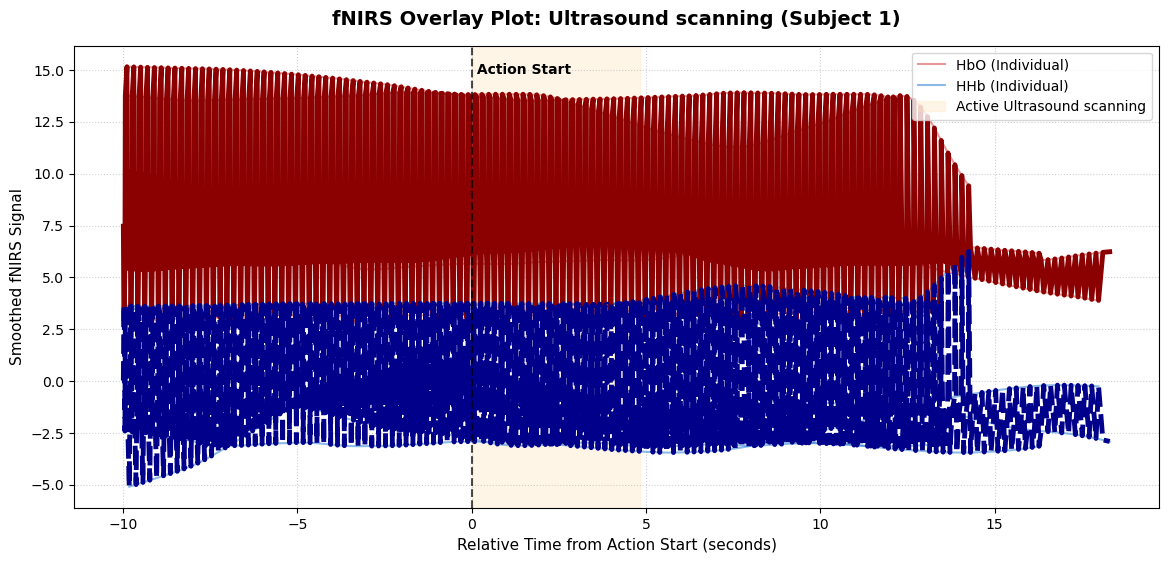

In [3]:

# ==========================================
# 1. 加载数据
# ==========================================
subj_id = '1'
sess_id = '1'
y_col = 'Var50'  # 真实有效通道

ts_data = pd.read_csv(f'cvc_time_series_data/ts_subj_{subj_id}_sess_{sess_id}.csv')
elan_df = pd.read_csv('CVC_0001_Annotations.csv')

# ==========================================
# 2. 清洗 ELAN 标签（确保匹配）
# ==========================================
elan_df['Clean_Text'] = elan_df['Text'].str.strip().str.replace(r'\s+', ' ', regex=True).str.capitalize()
correction_dict = {
    'Postion check (ultrasound)': 'Position check (ultrasound)',
    'Ultrasound  scanning': 'Ultrasound scanning',
    'Wire in and minimal advancement': 'Wire advancement'
}
elan_df['Clean_Text'] = elan_df['Clean_Text'].replace(correction_dict)

# ==========================================
# 3. 平滑处理（抹平毛刺，像 Jess 的图一样丝滑）
# ==========================================
ts_data['Smoothed'] = ts_data.groupby('signal')[y_col].transform(lambda x: x.rolling(window=30, min_periods=1).mean())

# ==========================================
# 4. 核心：选择你想要叠加观察的特定手术步骤 (Epoching)
# ==========================================
# 比如我们想看医生做 "Ultrasound scanning" (超声扫描) 时的所有脑血流变化
target_stage = 'Ultrasound scanning'
selected_events = elan_df[elan_df['Clean_Text'] == target_stage]

# 用来存放切下来的所有片段数据
epoch_list = []

print(f"开始提取动作 [{target_stage}]，共找到 {len(selected_events)} 个重复片段...")

# 遍历所有该动作发生的时刻，进行切片
for idx, row in selected_events.iterrows():
    # 将毫秒换算成秒
    start_sec = row['Start_ms'] / 1000.0
    end_sec = row['End_ms'] / 1000.0
    
    # 从 fNIRS 时序数据中，把这段时间的数据挖出来
    # 为了让图表前后有对比，我们把动作前 10 秒和后 10 秒的数据也切进来
    padding = 10 
    segment = ts_data[(ts_data['timestamp'] >= (start_sec - padding)) & 
                      (ts_data['timestamp'] <= (end_sec + padding))].copy()
    
    if not segment.empty:
        # 【关键魔法】：把真实的时间戳，重置为以“动作开始点”为 0 秒的相对时间
        # 这样所有的片段才能在 X 轴上对齐重叠！
        segment['Relative_Time'] = segment['timestamp'] - start_sec
        segment['Trial_ID'] = f"Attempt_{idx+1}" # 标记这是第几次做这个动作
        
        epoch_list.append(segment)

# 合并所有切片数据
if epoch_list:
    plot_data = pd.concat(epoch_list)
    
    # ==========================================
    # 5. 开始绘制 Jess 风格的叠加折线图
    # ==========================================
    plt.figure(figsize=(14, 6))
    
    # 按照信号类型画图：HbO 用红线系列，HHb 用蓝线系列
    # units='Trial_ID' 和 estimator=None 是 Seaborn 的高级画法，代表把每根线独立画出来，不进行平均合并
    sns.lineplot(data=plot_data[plot_data['signal'] == 1], 
                 x='Relative_Time', y='Smoothed', units='Trial_ID', estimator=None,
                 color='#d32f2f', alpha=0.5, linewidth=1.5, label='HbO (Individual)')
                 
    sns.lineplot(data=plot_data[plot_data['signal'] == 2], 
                 x='Relative_Time', y='Smoothed', units='Trial_ID', estimator=None,
                 color='#1976d2', alpha=0.5, linewidth=1.5, label='HHb (Individual)')
    
    # 加上一条亮眼的粗线，代表这几次尝试的【平均值趋势】（Jess 图里那种显眼的粗线）
    sns.lineplot(data=plot_data, x='Relative_Time', y='Smoothed', hue='signal',
                 palette={1: '#8b0000', 2: '#00008b'}, linewidth=3.5, style='signal', legend=False)

    # 6. 精准复刻 Jess 的阴影色块：标记出动作正在进行的区间 (0 秒 到 动作平均持续时间)
    avg_duration = (selected_events['End_ms'] - selected_events['Start_ms']).mean() / 1000.0
    plt.axvspan(0, avg_duration, color='#ffe0b2', alpha=0.3, label=f'Active {target_stage}')
    
    # 绘制 0 秒垂直分界线（代表动作开始的瞬间）
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
    plt.text(0, plt.ylim()[1]*0.95, ' Action Start ', ha='left', va='top', fontsize=10, fontweight='bold', color='black')

    # 整理图例（防止重复显示）
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    # 只保留我们关心的标签
    keep_labels = ['HbO (Individual)', 'HHb (Individual)', f'Active {target_stage}']
    plt.legend([by_label[l] for l in keep_labels if l in by_label], [l for l in keep_labels if l in by_label], loc='upper right')

    # 界面美化
    plt.title(f"fNIRS Overlay Plot: {target_stage} (Subject {subj_id})", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Relative Time from Action Start (seconds)", fontsize=11)
    plt.ylabel("Smoothed fNIRS Signal", fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.savefig(f'Jess_True_Style_{target_stage.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("未找到有效片段，请检查标签名称。")

正在提取动作 [Ultrasound scanning]... 共找到 9 个重复片段进行叠加。


c:\Users\Alice\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Alice\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Alice\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Alice\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

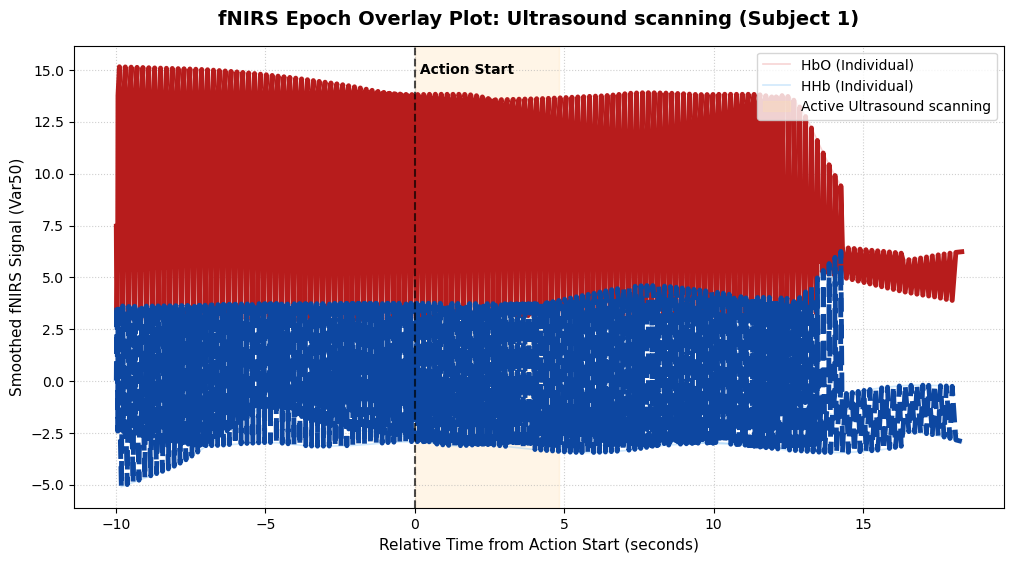

🌟 完美复刻 Jess 风格的叠加分析图已生成并保存为: Jess_True_Style_Ultrasound_scanning.png


In [4]:


# ==========================================
# 1. 设定参数与数据加载
# ==========================================
subj_id = '1'
sess_id = '1'
y_col = 'Var50'  # 你的 CVC 有效脑血流信号通道

# 读取你的 CVC 时序数据
ts_data = pd.read_csv(f'cvc_time_series_data/ts_subj_{subj_id}_sess_{sess_id}.csv')
# 读取我们刚从 .eaf 提取出的 106 个微观标注
elan_df = pd.read_csv('CVC_0001_Annotations.csv')

# ==========================================
# 2. 自动化数据清洗（适配标签格式）
# ==========================================
elan_df['Clean_Text'] = elan_df['Text'].str.strip().str.replace(r'\s+', ' ', regex=True).str.capitalize()
correction_dict = {
    'Postion check (ultrasound)': 'Position check (ultrasound)',
    'Ultrasound  scanning': 'Ultrasound scanning',
    'Wire in and minimal advancement': 'Wire advancement'
}
elan_df['Clean_Text'] = elan_df['Clean_Text'].replace(correction_dict)

# ==========================================
# 3. 信号平滑处理（抹平毛刺，复刻 Jess 的丝滑感）
# ==========================================
ts_data['Smoothed'] = ts_data.groupby('signal')[y_col].transform(lambda x: x.rolling(window=30, min_periods=1).mean())

# ==========================================
# 4. 【核心步骤】：选择你要叠加观察的特定手术动作
# ==========================================
# 你可以换成 'Venipuncture'、'Wire advancement' 或 'Dilator'
target_stage = 'Ultrasound scanning' 
selected_events = elan_df[elan_df['Clean_Text'] == target_stage]

epoch_list = []
padding_sec = 10  # 动作为中心，前后各多切出 10 秒用来观察对比基线

print(f"正在提取动作 [{target_stage}]... 共找到 {len(selected_events)} 个重复片段进行叠加。")

# 遍历每一个时间点进行切片
for idx, row in selected_events.iterrows():
    # ELAN 的毫秒转换为秒
    start_sec = row['Start_ms'] / 1000.0
    end_sec = row['End_ms'] / 1000.0
    
    # 提取前后包含 padding 的时序数据
    segment = ts_data[(ts_data['timestamp'] >= (start_sec - padding_sec)) & 
                      (ts_data['timestamp'] <= (end_sec + padding_sec))].copy()
    
    if not segment.empty:
        # 【核心魔法】：将绝对时间轴重置为以“动作开始点”为 0 秒的相对时间
        segment['Relative_Time'] = segment['timestamp'] - start_sec
        segment['Trial_ID'] = f"Attempt_{idx+1}"  # 标记第几次尝试
        epoch_list.append(segment)

# ==========================================
# 5. 绘制 Jess 真正的片段叠加图
# ==========================================
if epoch_list:
    plot_data = pd.concat(epoch_list)
    
    plt.figure(figsize=(12, 6))
    
    # 画法 A：画出每一次重复操作的单条细折线 (HbO为红，HHb为蓝，设置 alpha=0.3 降低透明度不至于太乱)
    # 这样图里就会出现密密麻麻很多条线的效果
    sns.lineplot(data=plot_data[plot_data['signal'] == 1], 
                 x='Relative_Time', y='Smoothed', units='Trial_ID', estimator=None,
                 color='#e57373', alpha=0.3, linewidth=1.2, label='HbO (Individual)')
                 
    sns.lineplot(data=plot_data[plot_data['signal'] == 2], 
                 x='Relative_Time', y='Smoothed', units='Trial_ID', estimator=None,
                 color='#64b5f6', alpha=0.3, linewidth=1.2, label='HHb (Individual)')
    
    # 画法 B：计算并画出所有尝试的【粗线平均趋势】（Jess 图里最亮眼、最粗的那两条主导线）
    sns.lineplot(data=plot_data, x='Relative_Time', y='Smoothed', hue='signal',
                 palette={1: '#b71c1c', 2: '#0d47a1'}, linewidth=3.5, style='signal', legend=False)

    # 6. 完美复刻 Jess 的核心阴影：标记出动作正在进行的区间 (0 秒 到 平均动作持续时间)
    avg_duration = (selected_events['End_ms'] - selected_events['Start_ms']).mean() / 1000.0
    plt.axvspan(0, avg_duration, color='#ffe0b2', alpha=0.3, label=f'Active {target_stage}')
    
    # 绘制 0 秒垂直切入线（动作触发瞬间）
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
    plt.text(0, plt.gca().get_ylim()[1]*0.95, ' Action Start ', ha='left', va='top', fontsize=10, fontweight='bold', color='black')

    # 图例去重美化
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    keep_labels = ['HbO (Individual)', 'HHb (Individual)', f'Active {target_stage}']
    plt.legend([by_label[l] for l in keep_labels if l in by_label], [l for l in keep_labels if l in by_label], loc='upper right')

    # 界面美化
    plt.title(f"fNIRS Epoch Overlay Plot: {target_stage} (Subject {subj_id})", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Relative Time from Action Start (seconds)", fontsize=11)
    plt.ylabel("Smoothed fNIRS Signal (Var50)", fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # 保存并展示
    output_name = f'Jess_True_Style_{target_stage.replace(" ", "_")}.png'
    plt.savefig(output_name, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"🌟 完美复刻 Jess 风格的叠加分析图已生成并保存为: {output_name}")
else:
    print("未找到有效数据片段，请检查标签白名单。")